# Informatyka w medycynie: Projekt 1 - Tomograf

Instalowanie paczek (odkomentować jeśli nie zainstalowano)

In [20]:
# %pip install Pillow matplotlib numpy scipy scikit-image

In [21]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import math
from sklearn.metrics import mean_squared_error
from skimage import draw
import sys

## 1. Sinogram

### 1.1. Wczytanie pliku

In [22]:
# Ścieżka do obrazu:

path = "tomograf-obrazy/.jpg"
# path = "tomograf-obrazy/Kolo.jpg"
# path = "tomograf-obrazy/Paski2.jpg"
path = "tomograf-obrazy/Shepp_logan.jpg"
# path = "tomograf-obrazy/Kropka.jpg"

Zmienna `image` przechowuje wczytany obraz z pliku (może być m.in. `.jpeg`, `.bmp` i `.png`).

Obraz konwertowany jest do skali szarości.

Indeksuje się: `image[ wiersz obrazu od góry ][ kolumna obrazu od lewej ]`

In [23]:
if os.path.exists(path):
    image_pil = Image.open(path).convert("L") # Konwersja do skali szarości
    image = np.array(image_pil)
else:
    print(f"Nie można znaleźć pliku {path}")

---

### 1.2. Prześwietlanie obrazu

#### Bresenham

Funkcja `skimage.draw.line` użyta poniżej korzysta z algorytmu Bresenhama.

In [24]:
def bresenham_sum(image, r0, c0, r1, c1):
    """Funkcja zwraca sumę wartości pikseli wzdłuż linii łączącej punkty `(r0, c0)` i `(r1, c1)`.
    Korzysta z algorytmu Bresenhama do wyznaczenia punktów na linii.
    Obsługuje `.jpg`, `.bmp`, `.png` i inne."""
    rr, cc = draw.line(r0, c0, r1, c1)
    
    # Tworzymy maskę logiczną dla punktów mieszczących się w wymiarach obrazu
    mask = (rr >= 0) & (rr < image.shape[0]) & (cc >= 0) & (cc < image.shape[1])
    
    # Sumujemy maskowane warości pikseli
    return np.sum(image[rr[mask], cc[mask]], dtype=np.float64)

# Nie używamy tej funkcji, ale zostawiamy ją w kodzie, bo może się jeszcze przydać
def bresenham_values(image, r0, c0, r1, c1):
    """Funkcja zwraca wartości pikseli wzdłuż linii łączącej punkty `(r0, c0)` i `(r1, c1)`.
    Korzysta z algorytmu Bresenhama do wyznaczenia punktów na linii.
    Obsługuje `.jpg`, `.bmp`, `.png` i inne."""
    rr, cc = draw.line(r0, c0, r1, c1)
    line_values = []
    for r, c in zip(rr, cc):
        if 0 <= r < image.shape[0] and 0 <= c < image.shape[1]:
            line_values.append(image[r, c])
        else:
            line_values.append(0)  # Dodaj 0, jeśli punkt jest poza obrazem
    return line_values

#### Obliczanie pozycji emiterów i detektorów

In [25]:
from dataclasses import dataclass
import numpy as np

# Wymagany Python 3.10+ dla tuple i list


@dataclass
class ScanIterationPositions:
    emitter_angle: float
    emitter_position: tuple[float, float]
    detector_positions: list[tuple[float, float]]


@dataclass
class ScanPositions:
    detector_spread_angle: float
    num_scans: int
    num_detectors: int
    scans: list[ScanIterationPositions]


def compute_scan_positions(
    num_detectors: int,
    spread_angle: float,
    num_steps: int,
    image_size: tuple[int, int],
    rotation_angle: float = 180.0,
) -> ScanPositions:
    """
    Funkcja oblicza pozycje emitera i detektorów dla każdego kroku skanowania. Zwraca obiekt `ScanPositions`.
    Kąty podawane w stopniach.
    Środek obrotu to środek obrazu.
    """

    # Współczynnik powiększający promień, aby emiter i detektory były poza obrazem
    padding_factor = 1.1

    # numpy bazowo daje wysokość jako pierwszą
    image_height, image_width = image_size
    c_x = (image_width - 1) / 2.0
    c_y = (image_height - 1) / 2.0
    r = np.sqrt(c_x**2 + c_y**2) * padding_factor

    scans = []

    # Kąt kroku rotacji
    step_angle = rotation_angle / num_steps

    phi = np.deg2rad(spread_angle)

    for step in range(num_steps):
        # alfa to kąt emitera względem osi x, liczony od pozycji startowej (0 stopni)
        # i rosnący w kierunku przeciwnym do ruchu wskazówek zegara
        alpha_deg = step * step_angle
        alpha = np.deg2rad(alpha_deg)

        # Pozycja emitera
        x_e = int(c_x + r * np.cos(alpha))
        y_e = int(c_y + r * np.sin(alpha))
        emitter_position = (x_e, y_e)

        detector_positions = []
        for i in range(num_detectors):
            # Gamma to kąt dla i-tego detektora wg wzoru z obrazka
            if num_detectors > 1:
                gamma = alpha + np.pi - phi / 2 + i * (phi / (num_detectors - 1))
            else:
                gamma = alpha + np.pi

            # Pozycja i-tego detektora
            x_d = int(c_x + r * np.cos(gamma))
            y_d = int(c_y + r * np.sin(gamma))
            detector_positions.append((x_d, y_d))

        scans.append(
            ScanIterationPositions(
                emitter_angle=alpha_deg,
                emitter_position=emitter_position,
                detector_positions=detector_positions,
            )
        )

    return ScanPositions(
        detector_spread_angle=spread_angle, num_scans=num_steps, num_detectors=num_detectors, scans=scans
    )

In [26]:
# # Podgląd zwracanych wartości dla przykładowych parametrów

# test1_scan_positions = compute_scan_positions(
#     num_detectors=180,
#     spread_angle=180,
#     num_steps=180,
#     image_size=image.shape,
#     rotation_angle=360.0,
# )
# for scan in test1_scan_positions.scans:
#     print(
#         f"Emitter angle: {scan.emitter_angle:.2f}°, Emitter pos: {scan.emitter_position}, Detector positions: {scan.detector_positions}"
#     )

#### Tworzenie i wyświetlanie sinogramu

In [27]:
def radon(image, scan_positions):
    """
    Funkcja oblicza sinogram dla danego obrazu i pozycji skanowania.
    Zwraca tablicę 2D numpy o wymiarach (num_scans, num_detectors) z sumami pikseli wzdłuż linii między emiterem a detektorami.
    """

    num_scans = scan_positions.num_scans
    num_detectors = scan_positions.num_detectors

    # Inicjalizacja sinogramu
    sinogram = np.zeros((num_scans, num_detectors))

    for i, scan in enumerate(scan_positions.scans):
        emitter_position = scan.emitter_position
        for j, detector_position in enumerate(scan.detector_positions):
            sinogram[i, j] = bresenham_sum(
                image,
                emitter_position[1],
                emitter_position[0],
                detector_position[1],
                detector_position[0],
            )

    return sinogram


def plot_sinogram(sinogram):
    """Funkcja wyświetla sinogram jako obraz 2D."""
    plt.imshow(sinogram, cmap="gray", aspect="equal")
    plt.colorbar(label="Suma pikseli")
    plt.xlabel("Detektor")
    plt.ylabel("Kąt skanowania (stopnie)")
    plt.title("Sinogram")
    plt.show()

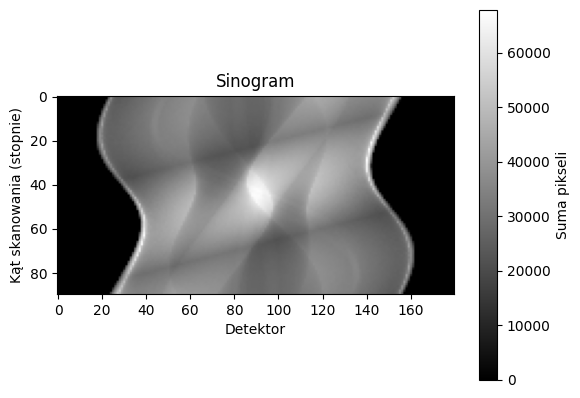

In [28]:
test2_scan_positions = compute_scan_positions(
    num_detectors=180,
    spread_angle=180,
    num_steps=90,
    image_size=image.shape,
    rotation_angle=180.0,
)

plot_sinogram(radon(image, test2_scan_positions))

In [ ]:
from IPython.display import display
import time
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np


def simulate_scan(
    image, scan_positions, delay=0.00, draw_every=1, ray_linewidth=1, ray_alpha=0.5
):
    """
    Symuluje proces skanowania krok po kroku, wyświetlając postęp skanowania.
    Korzysta z wyliczonego wcześniej całego sinogramu za pomocą funkcji `radon`.

    :param image: obraz
    :param scan_positions: obiekt ScanPositions
    :param delay: opóźnienie w sekundach między krokami wizualizacji
    :param draw_every: liczba co ile kroków ma być rysowany widok
    :param ray_linewidth: konfuguruje grubość linii promieni skanowania
    :param ray_alpha: konfiguruje przezroczystość promieni skanowania
    """

    # Wyliczanie całego sinogramu z pomocą autorskiej funkcji radon
    full_sinogram = radon(image, scan_positions)

    sinogram = np.zeros((scan_positions.num_scans, scan_positions.num_detectors))

    with plt.style.context("dark_background"):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        ax1.imshow(image, cmap="gray", zorder=0)
        height, width = image.shape
        margin = np.hypot(width, height) / 2 * 1.5
        ax1.set(
            xlim=(width / 2 - margin, width / 2 + margin),
            ylim=(height / 2 + margin, height / 2 - margin),
            title="Emiter",
        )

        rays = ax1.add_collection(
            LineCollection(
                [],
                colors="#e82309",
                alpha=ray_alpha,
                linewidths=ray_linewidth,
                zorder=1,
            )
        )
        scat_det = ax1.scatter([], [], color="#a528d6", s=10, label="Detektory", zorder=3)
        scat_emit = ax1.scatter([], [], color="#f4af24", s=50, label="Emiter", zorder=4)

        im2 = ax2.imshow(sinogram, cmap="gray", aspect="equal", vmin=0, vmax=1)
        ax2.set(title="Sinogram", xlabel="Detektor", ylabel="Kąt")

        plt.tight_layout()
        display_handle = display(fig, display_id=True)

        max_intensity_threshold = 0

        for i, scan in enumerate(scan_positions.scans):
            emit_pos = scan.emitter_position
            is_draw_step = i % draw_every == 0 or i == scan_positions.num_scans - 1
            segments = []

            # 1. Dodanie kolejnego wiersza do sinogramu
            sinogram[i, :] = full_sinogram[i, :]

            # 2. Budowanie segmentów promieni
            if is_draw_step:
                for det_pos in scan.detector_positions:
                    segments.append([emit_pos, det_pos])

            # 3. Aktualizacja plotów
            if is_draw_step:
                im2.set_data(sinogram)

                step_max_intensity = np.max(sinogram[i])
                if step_max_intensity > max_intensity_threshold:
                    max_intensity_threshold = step_max_intensity
                    im2.set_clim(vmax=max_intensity_threshold)

                scat_emit.set_offsets([emit_pos])
                scat_det.set_offsets(scan.detector_positions)
                rays.set_segments(segments)

                ax1.set_title(f"Emiter - Kąt: {scan.emitter_angle:.1f}°")
                ax2.set_title(f"Sinogram (Krok {i+1}/{scan_positions.num_scans})")

                if display_handle:
                    display_handle.update(fig)
                time.sleep(delay)

    plt.close(fig)

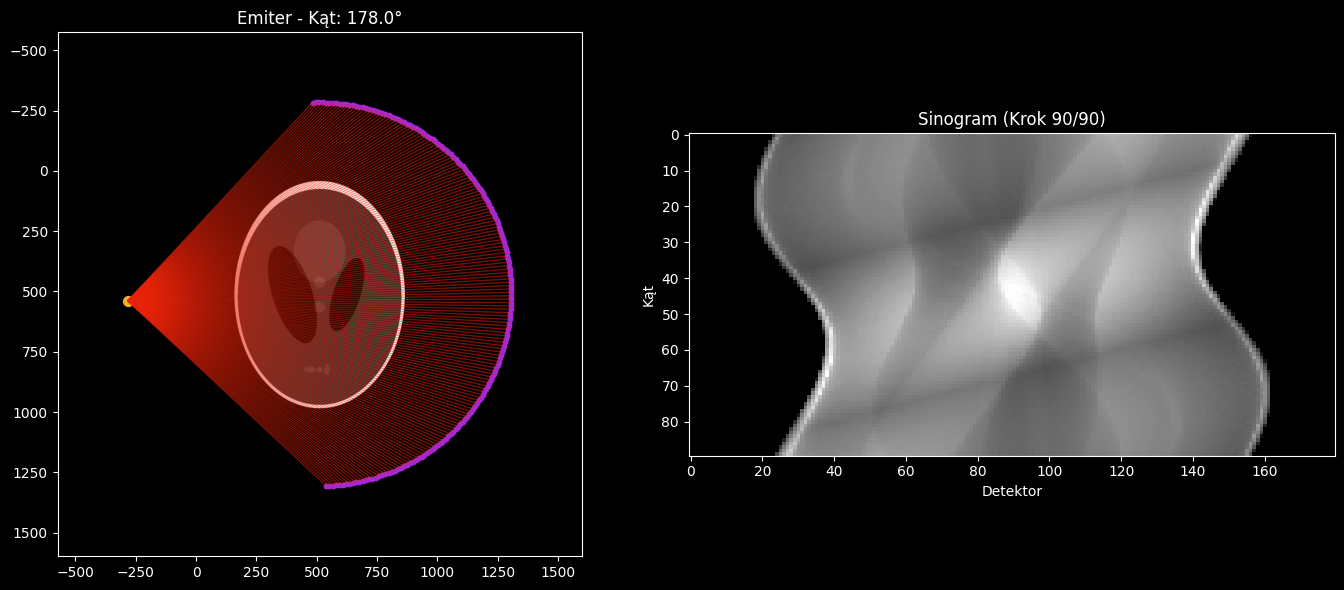

In [36]:
simulate_scan(
    image,
    test2_scan_positions,
    draw_every=5,
)